# 01 - PREPARE DATASET

In [ ]:
import os
import csv
import re
import wfdb
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
import os
import wfdb
import pandas as pd



## 1 - VALIDATE ECG DATASET

In [45]:
# Validate ECG Dataset
#/Volumes/KINGSTON/MIMIC-IV/ECG/
ecg_root = '/Volumes/KINGSTON/MIMIC-IV/ECG/files'
log_file = 'LOGS/ecg_validation_log.csv'

# Inicializa el archivo de log si no existe
if not os.path.exists('LOGS'):
    os.makedirs('LOGS')
if not os.path.exists(log_file):
    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['folder', 'subject_id', 'test_id', 'hea_exists', 'dat_exists', 'hea_size', 'dat_size', 'subject_id_match', 'hea_filename', 'dat_filename', 'status', 'error', 'signal_status'])

for root, dirs, files in os.walk(ecg_root):
    # Solo carpetas finales (sin subcarpetas)
    if not dirs:
        folder = root
        hea_files = [f for f in files if f.endswith('.hea')]
        dat_files = [f for f in files if f.endswith('.dat')]
        hea_exists = len(hea_files) > 0
        dat_exists = len(dat_files) > 0
        hea_size = os.path.getsize(os.path.join(root, hea_files[0])) if hea_exists else 0
        dat_size = os.path.getsize(os.path.join(root, dat_files[0])) if dat_exists else 0
        subject_folder = os.path.basename(os.path.dirname(folder))
        subject_id = int(subject_folder[1:])
        test_id = os.path.basename(root)
        test_id = test_id[1:] if test_id.startswith('s') else test_id
        test_id_match = False
        hea_filename = hea_files[0] if hea_exists else ''
        dat_filename = dat_files[0] if dat_exists else ''
        error = ''
        status = 'OK'
        signal_status = ''

        # Validar subject_id en archivo .hea (busca en todas las líneas)
        if hea_exists:
            try:
                with open(os.path.join(root, hea_filename), 'r') as f:
                    lines = f.readlines()
                    found_id = None
                    for line in lines:
                        match = re.search(r'(\d{7,8})', line)
                        if match:
                            found_id = match.group(1)
                            break
                    if found_id:
                        file_subject_id = found_id
                        test_id_match = (file_subject_id == test_id)
                    else:
                        test_id_match = False
                        error = 'No se encontró subject_id en .hea'
            except Exception as e:
                error = str(e)
                status = 'ERROR'

        if not hea_exists or not dat_exists:
            status = 'FALTAN ARCHIVOS'
            error = 'No existe .hea o .dat'
        elif hea_size == 0 or dat_size == 0:
            status = 'ARCHIVO VACÍO'
            error = 'Archivo .hea o .dat vacío'
        elif not test_id_match:
            status = 'TEST ID NO COINCIDE'
            if not error: error = 'test_id no coincide entre carpeta y .hea'

        # Validación de señal con wfdb.rdrecord
        if hea_exists and dat_exists and status == 'OK':
            try:
                record_path = os.path.join(root, hea_filename).replace('.hea', '')
                record = wfdb.rdrecord(record_path)
                if hasattr(record, 'p_signal') and record.p_signal is not None and record.p_signal.shape[0] > 0 and record.p_signal.shape[1] > 0:
                    signal_status = 'SIGNAL_OK'
                else:
                    signal_status = 'SIGNAL_EMPTY'
                    status = 'SEÑAL VACÍA'
            except Exception as e:
                signal_status = f'SIGNAL_ERROR: {str(e)}'
                if "Samples were not loaded correctly" not in str(e):
                    print(f"Archivo problemático {hea_filename}: {e}")
                status = 'SEÑAL ERROR'

        # Registrar en el log
        with open(log_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([folder, subject_id, test_id, hea_exists, dat_exists, hea_size, dat_size, test_id_match, hea_filename, dat_filename, status, error, signal_status])
print("Validación completada. Revisa 'LOGS/ecg_validation_log.csv' para detalles.")

Validación completada. Revisa 'LOGS/ecg_validation_log.csv' para detalles.


## 2 - VALIDATE ECG DATA

In [46]:
# Crear ecg_deep_learning_dataset.csv a partir de los registros validados

# Cargar validaciones de ECG
validation_log = pd.read_csv('LOGS/ecg_validation_log.csv')
# Cargar dataset de cirugía cardíaca con ECG
ecg_dataset = pd.read_csv('aux_dataset/ecg_cardiac_surgery_dataset.csv')

valid_ecg = validation_log[(validation_log['status'] == 'OK') & (validation_log['signal_status'] == 'SIGNAL_OK')]

# Filtrar solo los registros con ECG válidos
valid_subject_ids = valid_ecg['subject_id'].astype(str).unique()
print(valid_subject_ids)
deep_learning_df = ecg_dataset[ecg_dataset['subject_id'].astype(str).isin(valid_subject_ids)]

# Guardar el nuevo dataset filtrado
deep_learning_df.to_csv('aux_dataset/ecg_validated_dataset.csv', index=False)
print(f'Guardado dataset validado en aux_dataset/ecg_validated_dataset.csv')

['10000635' '10000980' '10001401' ... '19998878' '19999379' '19999784']
Guardado dataset validado en aux_dataset/ecg_validated_dataset.csv


In [47]:
# Generar ecg_validated_dataset.csv con columnas folder y hea_filename
validation_log = pd.read_csv('LOGS/ecg_validation_log.csv')
ecgs_ok = validation_log[(validation_log['status'] == 'OK') & (validation_log['signal_status'] == 'SIGNAL_OK')]
ecgs_ok = ecgs_ok[['subject_id', 'folder', 'hea_filename']]

# Cargar dataset de cirugía cardíaca con ECG
ecg_dataset = pd.read_csv('aux_dataset/ecg_cardiac_surgery_dataset.csv')

# Unir por subject_id y test_id
merged = pd.merge(ecg_dataset, ecgs_ok, on=['subject_id', ], how='inner')

# Guardar el nuevo dataset filtrado con las columnas necesarias
merged.to_csv('aux_dataset/ecg_validated_dataset.csv', index=False)
print('Guardado dataset validado en aux_dataset/ecg_validated_dataset.csv con folder y hea_filename.')

Guardado dataset validado en aux_dataset/ecg_validated_dataset.csv con folder y hea_filename.


In [50]:
#abrir ecg_validated_dataset.csv y borrar duplicados
import pandas as pd
df = pd.read_csv('aux_dataset/ecg_validated_dataset.csv')
if 'test_id' in df.columns:
    df = df.drop_duplicates(subset=['subject_id', 'test_id'])
else:
    df = df.drop_duplicates(subset=['subject_id'])
df.to_csv('aux_dataset/ecg_validated_dataset.csv', index=False)
print('Duplicados eliminados en aux_dataset/ecg_validated_dataset.csv.')

Duplicados eliminados en aux_dataset/ecg_validated_dataset.csv.


## 3 - CREATE DATASETS

## 3.1 - DATASET 1 (RAW 10S)

In [64]:
class ECGDataset(Dataset):

    def __init__(self, csv_path, sample_rate=500, seconds=10, label_col='mortality_30d'):
        self.df = pd.read_csv(csv_path)
        self.root = '/Volumes/KINGSTON/MIMIC-IV/ECG/files/'
        self.sample_rate = sample_rate
        self.seconds = seconds
        # Crear diccionario de labels
        if label_col in self.df.columns:
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_col]))
        else:
            # Si no existe la columna label, usar la primera columna distinta de subject_id
            label_candidates = [col for col in self.df.columns if col != 'subject_id']
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_candidates[0]]))

    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        retries = 0
        while retries < 3:
            row = self.df.iloc[idx]
            subject_id = row['subject_id']
            test_id = row['test_id'] if 'test_id' in row else None
            hea_file = row['hea_filename'] if 'hea_filename' in row else None
            folder = row['folder'] if 'folder' in row else None

            try:
                # Validar columnas
                if folder is None or hea_file is None:
                    raise ValueError("Faltan columnas 'folder' o 'hea_filename' en el dataset")

                record_path = os.path.join(folder, hea_file).replace('.hea', '')
                record = wfdb.rdrecord(record_path)
                signal = record.p_signal

                if signal is None:
                    raise ValueError("Señal vacía en el archivo")

                # Asegurar 12 derivaciones
                if signal.shape[1] < 12:
                    signal = np.pad(signal, ((0, 0), (0, 12 - signal.shape[1])), mode="constant")
                elif signal.shape[1] > 12:
                    signal = signal[:, :12]

                # Ajustar duración
                samples_needed = self.sample_rate * self.seconds
                num_samples = len(signal)
                if num_samples > samples_needed:
                    start_idx = np.random.randint(0, num_samples - samples_needed + 1)
                    signal = signal[start_idx:start_idx + samples_needed, :]
                elif num_samples < samples_needed:
                    signal = np.pad(signal, ((0, samples_needed - num_samples), (0, 0)), mode="constant")

                # Preprocesamiento
                signal = np.nan_to_num(signal)
                std_vals = np.std(signal, axis=0)
                std_vals[std_vals == 0] = 1
                signal = (signal - np.mean(signal, axis=0)) / std_vals

                # Label
                label = self.labels_dict[subject_id]
                return torch.tensor(signal, dtype=torch.float32).T, torch.tensor(float(label), dtype=torch.float32)

            except Exception as e:
                print(f"[WARN] Error procesando {hea_file}: {e}. Reintentando con otro índice...")
                idx = np.random.randint(0, len(self.df))  # escoger otro índice aleatorio
                retries += 1

        # Si falla tras 3 intentos → lanzar error
        raise RuntimeError(f"No se pudo cargar la muestra después de {retries} intentos")

    def __getitemOLD__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        test_id = row['test_id'] if 'test_id' in row else None
        hea_file = row['hea_filename'] if 'hea_filename' in row else None
        folder = row['folder'] if 'folder' in row else None
        try:
            # Verifica que las columnas existan
            if folder is None or hea_file is None:
                raise ValueError('Faltan columnas folder o hea_filename en el dataset')
            record_path = os.path.join(folder, hea_file).replace('.hea', '')
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal

            if signal is None:
                raise ValueError("Señal es None")

            # Asegurar 12 derivaciones
            if signal.shape[1] < 12:
                signal = np.pad(signal, ((0, 0), (0, 12 - signal.shape[1])), mode='constant')
            elif signal.shape[1] > 12:
                signal = signal[:, :12]

            # Ajustar duración
            samples_needed = self.sample_rate * self.seconds
            num_samples = len(signal)
            if num_samples > samples_needed:
                start_idx = np.random.randint(0, num_samples - samples_needed + 1)
                signal = signal[start_idx:start_idx + samples_needed, :]
            elif num_samples < samples_needed:
                signal = np.pad(signal, ((0, samples_needed - num_samples), (0, 0)), mode='constant')

            # Reemplazar NaN e infinitos
            signal = np.nan_to_num(signal)

            # Normalización por canal
            std_vals = np.std(signal, axis=0)
            std_vals[std_vals == 0] = 1
            signal = (signal - np.mean(signal, axis=0)) / std_vals

            label = self.labels_dict[subject_id]
            return torch.tensor(signal, dtype=torch.float32).T, torch.tensor(float(label), dtype=torch.float32)
        except Exception as e:
            print(f"Error procesando {hea_file}: {e}")
            dummy_signal = np.zeros((12, self.sample_rate * self.seconds))
            return torch.tensor(dummy_signal, dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)


In [65]:

# Cargar el dataset filtrado
csv_path = 'aux_dataset/ecg_validated_dataset.csv'
ecg_dataset = ECGDataset(csv_path)

print(f'Dataset cargado con {len(ecg_dataset)} muestras.')

#number of sampled of ecg_validated_dataset.csv with mortality_30d False
print(f'Death patients {ecg_dataset.df["mortality_30d"].sum()}')
print(f'Survival patients {len(ecg_dataset) - ecg_dataset.df["mortality_30d"].sum()}')

Dataset cargado con 26048 muestras.
Death patients 1273
Survival patients 24775


## 3.2 - DATASET 3 (RAW 5s)

In [1]:
class ECG2(Dataset):

    def __init__(self, csv_path, sample_rate=500, seconds=5, label_col='mortality_30d'):
        self.df = pd.read_csv(csv_path)
        self.root = '/Volumes/KINGSTON/MIMIC-IV/ECG/files/'
        self.sample_rate = sample_rate
        self.seconds = seconds
        # Crear diccionario de labels
        if label_col in self.df.columns:
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_col]))
        else:
            label_candidates = [col for col in self.df.columns if col != 'subject_id']
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_candidates[0]]))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        retries = 0
        while retries < 3:
            row = self.df.iloc[idx]
            subject_id = row['subject_id']
            test_id = row['test_id'] if 'test_id' in row else None
            hea_file = row['hea_filename'] if 'hea_filename' in row else None
            folder = row['folder'] if 'folder' in row else None

            try:
                # Validar columnas
                if folder is None or hea_file is None:
                    raise ValueError("Faltan columnas 'folder' o 'hea_filename' en el dataset")

                record_path = os.path.join(folder, hea_file).replace('.hea', '')
                record = wfdb.rdrecord(record_path)
                signal = record.p_signal

                if signal is None:
                    raise ValueError("Señal vacía en el archivo")

                # Asegurar 12 derivaciones
                if signal.shape[1] < 12:
                    signal = np.pad(signal, ((0, 0), (0, 12 - signal.shape[1])), mode="constant")
                elif signal.shape[1] > 12:
                    signal = signal[:, :12]

                # Ajustar duración: extraer los 5 segundos centrales
                samples_needed = self.sample_rate * self.seconds
                num_samples = len(signal)
                if num_samples >= samples_needed:
                    start_idx = (num_samples - samples_needed) // 2
                    signal = signal[start_idx:start_idx + samples_needed, :]
                else:
                    # Si la señal es más corta, rellenar con ceros centrando la señal
                    pad_before = (samples_needed - num_samples) // 2
                    pad_after = samples_needed - num_samples - pad_before
                    signal = np.pad(signal, ((pad_before, pad_after), (0, 0)), mode="constant")

                # Preprocesamiento
                signal = np.nan_to_num(signal)
                std_vals = np.std(signal, axis=0)
                std_vals[std_vals == 0] = 1
                signal = (signal - np.mean(signal, axis=0)) / std_vals

                # Label
                label = self.labels_dict[subject_id]
                return torch.tensor(signal, dtype=torch.float32).T, torch.tensor(float(label), dtype=torch.float32)

            except Exception as e:
                print(f"[WARN] Error procesando {hea_file}: {e}. Reintentando con otro índice...")
                idx = np.random.randint(0, len(self.df))  # escoger otro índice aleatorio
                retries += 1

        # Si falla tras 3 intentos → lanzar error
        raise RuntimeError(f"No se pudo cargar la muestra después de {retries} intentos")

    def __getitemOLD__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        test_id = row['test_id'] if 'test_id' in row else None
        hea_file = row['hea_filename'] if 'hea_filename' in row else None
        folder = row['folder'] if 'folder' in row else None
        try:
            # Verifica que las columnas existan
            if folder is None or hea_file is None:
                raise ValueError('Faltan columnas folder o hea_filename en el dataset')
            record_path = os.path.join(folder, hea_file).replace('.hea', '')
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal

            if signal is None:
                raise ValueError("Señal es None")

            # Asegurar 12 derivaciones
            if signal.shape[1] < 12:
                signal = np.pad(signal, ((0, 0), (0, 12 - signal.shape[1])), mode='constant')
            elif signal.shape[1] > 12:
                signal = signal[:, :12]

            # Ajustar duración: extraer los 5 segundos centrales
            samples_needed = self.sample_rate * self.seconds
            num_samples = len(signal)
            if num_samples >= samples_needed:
                start_idx = (num_samples - samples_needed) // 2
                signal = signal[start_idx:start_idx + samples_needed, :]
            else:
                pad_before = (samples_needed - num_samples) // 2
                pad_after = samples_needed - num_samples - pad_before
                signal = np.pad(signal, ((pad_before, pad_after), (0, 0)), mode='constant')

            # Reemplazar NaN e infinitos
            signal = np.nan_to_num(signal)

            # Normalización por canal
            std_vals = np.std(signal, axis=0)
            std_vals[std_vals == 0] = 1
            signal = (signal - np.mean(signal, axis=0)) / std_vals

            label = self.labels_dict[subject_id]
            return torch.tensor(signal, dtype=torch.float32).T, torch.tensor(float(label), dtype=torch.float32)
        except Exception as e:
            print(f"Error procesando {hea_file}: {e}")
            dummy_signal = np.zeros((12, self.sample_rate * self.seconds))
            return torch.tensor(dummy_signal, dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)

NameError: name 'Dataset' is not defined

In [58]:
# Cargar el dataset filtrado
csv_path = 'aux_dataset/ecg_validated_dataset.csv'
ecg_dataset = ECG2(csv_path)

print(f'Dataset cargado con {len(ecg_dataset)} muestras.')

#number of sampled of ecg_validated_dataset.csv with mortality_30d False
print(f'Death patients {ecg_dataset.df["mortality_30d"].sum()}')
print(f'Survival patients {len(ecg_dataset) - ecg_dataset.df["mortality_30d"].sum()}')

Dataset cargado con 26048 muestras.
Death patients 1273
Survival patients 24775


## 3.2 - DATASET 2 (RAW 5s)

In [43]:
class ECGDatasetAug(Dataset):
    def __init__(self, csv_path, sample_rate=500, seconds=10, label_col='mortality_30d', augment=False):
        self.df = pd.read_csv(csv_path)
        self.sample_rate = sample_rate
        self.seconds = seconds
        self.augment = augment

        # Diccionario de labels
        if label_col in self.df.columns:
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_col]))
        else:
            label_candidates = [col for col in self.df.columns if col != 'subject_id']
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_candidates[0]]))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        folder = row.get('folder', None)
        hea_file = row.get('hea_filename', None)

        if folder is None or hea_file is None:
            raise ValueError(f"Faltan columnas 'folder' o 'hea_filename' para el índice {idx}")

        record_path = os.path.join(folder, hea_file).replace('.hea', '')
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal

        if signal is None:
            raise ValueError(f"Señal vacía en {hea_file}")

        # Asegurar 12 derivaciones
        if signal.shape[1] < 12:
            signal = np.pad(signal, ((0,0),(0,12 - signal.shape[1])), mode='constant')
        elif signal.shape[1] > 12:
            signal = signal[:, :12]

        # Ajustar duración
        samples_needed = self.sample_rate * self.seconds
        num_samples = len(signal)
        if num_samples > samples_needed:
            start_idx = np.random.randint(0, num_samples - samples_needed + 1)
            signal = signal[start_idx:start_idx+samples_needed, :]
        elif num_samples < samples_needed:
            signal = np.pad(signal, ((0, samples_needed - num_samples),(0,0)), mode='constant')

        # Data augmentation solo si es clase minoritaria y augment=True
        label = self.labels_dict[subject_id]
        if self.augment and label == 1:
            signal = self.ecg_augment(signal)

        # Normalización z-score por canal
        signal = np.nan_to_num(signal)
        std_vals = np.std(signal, axis=0)
        std_vals[std_vals == 0] = 1
        signal = (signal - np.mean(signal, axis=0)) / std_vals

        return torch.tensor(signal.T, dtype=torch.float32), torch.tensor(float(label), dtype=torch.float32)

    # -----------------------------
    # Función simple de augmentation
    # -----------------------------
    def ecg_augment(self, signal):
        # Ruido gaussiano leve
        noise = np.random.normal(0, 0.01, signal.shape)
        signal = signal + noise

        # Pequeño shift temporal
        shift = np.random.randint(-50, 50)
        signal = np.roll(signal, shift, axis=0)

        # Escalado de amplitud
        scale = np.random.uniform(0.9, 1.1, size=(1, signal.shape[1]))
        signal = signal * scale

        return signal


In [54]:

# -----------------------------
# Cargar dataset
# -----------------------------
csv_path = 'aux_dataset/ecg_validated_dataset.csv'
ecg_dataset = ECGDatasetAug(csv_path, augment=True)

# -----------------------------
# WeightedRandomSampler para balance
# -----------------------------
labels = ecg_dataset.df['mortality_30d'].values
# Asegurar que labels sean enteros (0 y 1)
labels = labels.astype(int)
class_counts = np.bincount(labels)
weights_per_class = 1.0 / class_counts
sample_weights = weights_per_class[labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


## 3.4 - DATASET 4 (AUGMENTED 5s)

In [91]:
class ECG4(Dataset):
    def __init__(self, csv_path, sample_rate=500, seconds=5, label_col='mortality_30d', augment=False):
        self.df = pd.read_csv(csv_path)
        self.sample_rate = sample_rate
        self.seconds = seconds
        self.augment = augment

        # Diccionario de labels
        if label_col in self.df.columns:
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_col]))
        else:
            label_candidates = [col for col in self.df.columns if col != 'subject_id']
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_candidates[0]]))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        folder = row.get('folder', None)
        hea_file = row.get('hea_filename', None)

        if folder is None or hea_file is None:
            raise ValueError(f"Faltan columnas 'folder' o 'hea_filename' para el índice {idx}")

        record_path = os.path.join(folder, hea_file).replace('.hea', '')
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal

        if signal is None:
            raise ValueError(f"Señal vacía en {hea_file}")

        # Asegurar 12 derivaciones
        if signal.shape[1] < 12:
            signal = np.pad(signal, ((0,0),(0,12 - signal.shape[1])), mode='constant')
        elif signal.shape[1] > 12:
            signal = signal[:, :12]

        # Ajustar duración: extraer los 5 segundos centrales
        samples_needed = self.sample_rate * self.seconds
        num_samples = len(signal)
        if num_samples >= samples_needed:
            start_idx = (num_samples - samples_needed) // 2
            signal = signal[start_idx:start_idx + samples_needed, :]
        else:
            pad_before = (samples_needed - num_samples) // 2
            pad_after = samples_needed - num_samples - pad_before
            signal = np.pad(signal, ((pad_before, pad_after), (0, 0)), mode='constant')

        # Data augmentation solo si es clase minoritaria y augment=True
        label = self.labels_dict[subject_id]
        if self.augment and label == 1:
            signal = self.ecg_augment(signal)

        # Normalización z-score por canal
        signal = np.nan_to_num(signal)
        std_vals = np.std(signal, axis=0)
        std_vals[std_vals == 0] = 1
        signal = (signal - np.mean(signal, axis=0)) / std_vals

        return torch.tensor(signal.T, dtype=torch.float32), torch.tensor(float(label), dtype=torch.float32)

    # -----------------------------
    # Función simple de augmentation
    # -----------------------------
    def ecg_augment(self, signal):
        # Ruido gaussiano leve
        noise = np.random.normal(0, 0.01, signal.shape)
        signal = signal + noise

        # Pequeño shift temporal
        shift = np.random.randint(-50, 50)
        signal = np.roll(signal, shift, axis=0)

        # Escalado de amplitud
        scale = np.random.uniform(0.9, 1.1, size=(1, signal.shape[1]))
        signal = signal * scale

        return signal

In [74]:

# -----------------------------
# Cargar dataset
# -----------------------------
csv_path = 'aux_dataset/ecg_validated_dataset.csv'
ecg_dataset = ECG4(csv_path, augment=True)

# -----------------------------
# WeightedRandomSampler para balance
# -----------------------------
labels = ecg_dataset.df['mortality_30d'].values
# Asegurar que labels sean enteros (0 y 1)
labels = labels.astype(int)
class_counts = np.bincount(labels)
weights_per_class = 1.0 / class_counts
sample_weights = weights_per_class[labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


## 3.5 - DATASET 5 (AUGMENTED 5s low sample rate)

In [86]:
class ECG5(Dataset):
    def __init__(self, csv_path, sample_rate=200, seconds=5, label_col='mortality_30d', augment=False):
        self.df = pd.read_csv(csv_path)
        self.sample_rate = sample_rate
        self.seconds = seconds
        self.augment = augment

        # Diccionario de labels
        if label_col in self.df.columns:
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_col]))
        else:
            label_candidates = [col for col in self.df.columns if col != 'subject_id']
            self.labels_dict = dict(zip(self.df['subject_id'], self.df[label_candidates[0]]))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        folder = row.get('folder', None)
        hea_file = row.get('hea_filename', None)

        if folder is None or hea_file is None:
            raise ValueError(f"Faltan columnas 'folder' o 'hea_filename' para el índice {idx}")

        record_path = os.path.join(folder, hea_file).replace('.hea', '')
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal

        if signal is None:
            raise ValueError(f"Señal vacía en {hea_file}")

        # Asegurar 12 derivaciones
        if signal.shape[1] < 12:
            signal = np.pad(signal, ((0,0),(0,12 - signal.shape[1])), mode='constant')
        elif signal.shape[1] > 12:
            signal = signal[:, :12]

        # Ajustar duración: extraer los 5 segundos centrales
        samples_needed = self.sample_rate * self.seconds
        num_samples = len(signal)
        if num_samples >= samples_needed:
            start_idx = (num_samples - samples_needed) // 2
            signal = signal[start_idx:start_idx + samples_needed, :]
        else:
            pad_before = (samples_needed - num_samples) // 2
            pad_after = samples_needed - num_samples - pad_before
            signal = np.pad(signal, ((pad_before, pad_after), (0, 0)), mode='constant')

        # Data augmentation solo si es clase minoritaria y augment=True
        label = self.labels_dict[subject_id]
        if self.augment and label == 1:
            signal = self.ecg_augment(signal)

        # Normalización z-score por canal
        signal = np.nan_to_num(signal)
        std_vals = np.std(signal, axis=0)
        std_vals[std_vals == 0] = 1
        signal = (signal - np.mean(signal, axis=0)) / std_vals

        return torch.tensor(signal.T, dtype=torch.float32), torch.tensor(float(label), dtype=torch.float32)

    # -----------------------------
    # Función simple de augmentation
    # -----------------------------
    def ecg_augment(self, signal):
        # Ruido gaussiano leve
        noise = np.random.normal(0, 0.01, signal.shape)
        signal = signal + noise

        # Pequeño shift temporal
        shift = np.random.randint(-50, 50)
        signal = np.roll(signal, shift, axis=0)

        # Escalado de amplitud
        scale = np.random.uniform(0.9, 1.1, size=(1, signal.shape[1]))
        signal = signal * scale

        return signal

In [87]:

# -----------------------------
# Cargar dataset
# -----------------------------
csv_path = 'aux_dataset/ecg_validated_dataset.csv'
ecg_dataset = ECG5(csv_path, augment=True)

# -----------------------------
# WeightedRandomSampler para balance
# -----------------------------
labels = ecg_dataset.df['mortality_30d'].values
# Asegurar que labels sean enteros (0 y 1)
labels = labels.astype(int)
class_counts = np.bincount(labels)
weights_per_class = 1.0 / class_counts
sample_weights = weights_per_class[labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


## 4 - SPLIT DATA (Train - Validate - Test)

In [88]:


# -----------------------------
# Dividir dataset
# -----------------------------
from sklearn.model_selection import train_test_split

train_test_idx, val_idx = train_test_split(range(len(ecg_dataset)), test_size=0.2, random_state=42,
                                          stratify=labels)
train_idx, test_idx = train_test_split(train_test_idx, test_size=0.2, random_state=42,
                                       stratify=labels[train_test_idx])

train_subset = torch.utils.data.Subset(ecg_dataset, train_idx)
test_subset = torch.utils.data.Subset(ecg_dataset, test_idx)
val_subset = torch.utils.data.Subset(ecg_dataset, val_idx)

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(train_subset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

print(f"Dataset total: {len(ecg_dataset)} muestras")
print(f"Entrenamiento: {len(train_subset)} muestras")
print(f"Prueba: {len(test_subset)} muestras")
print(f"Validación: {len(val_subset)} muestras")


Dataset total: 26048 muestras
Entrenamiento: 16670 muestras
Prueba: 4168 muestras
Validación: 5210 muestras


In [69]:
# Verificar que podemos cargar un batch sin errores
try:
    for signals, labels in train_loader:
        print(f"Forma de señales: {signals.shape}")
        print(f"Forma de labels: {labels.shape}")
        print(f"Distribución de labels: {torch.bincount(labels.long())}")
        break
except Exception as e:
    print(f"Error al cargar batch: {e}")

# Verifica los valores únicos en los labels
#print(torch.unique(labels))
labels_tensor = torch.tensor(labels) if not isinstance(labels, torch.Tensor) else labels
print(torch.unique(labels_tensor))

Error al cargar batch: list index out of range
tensor([0, 1])


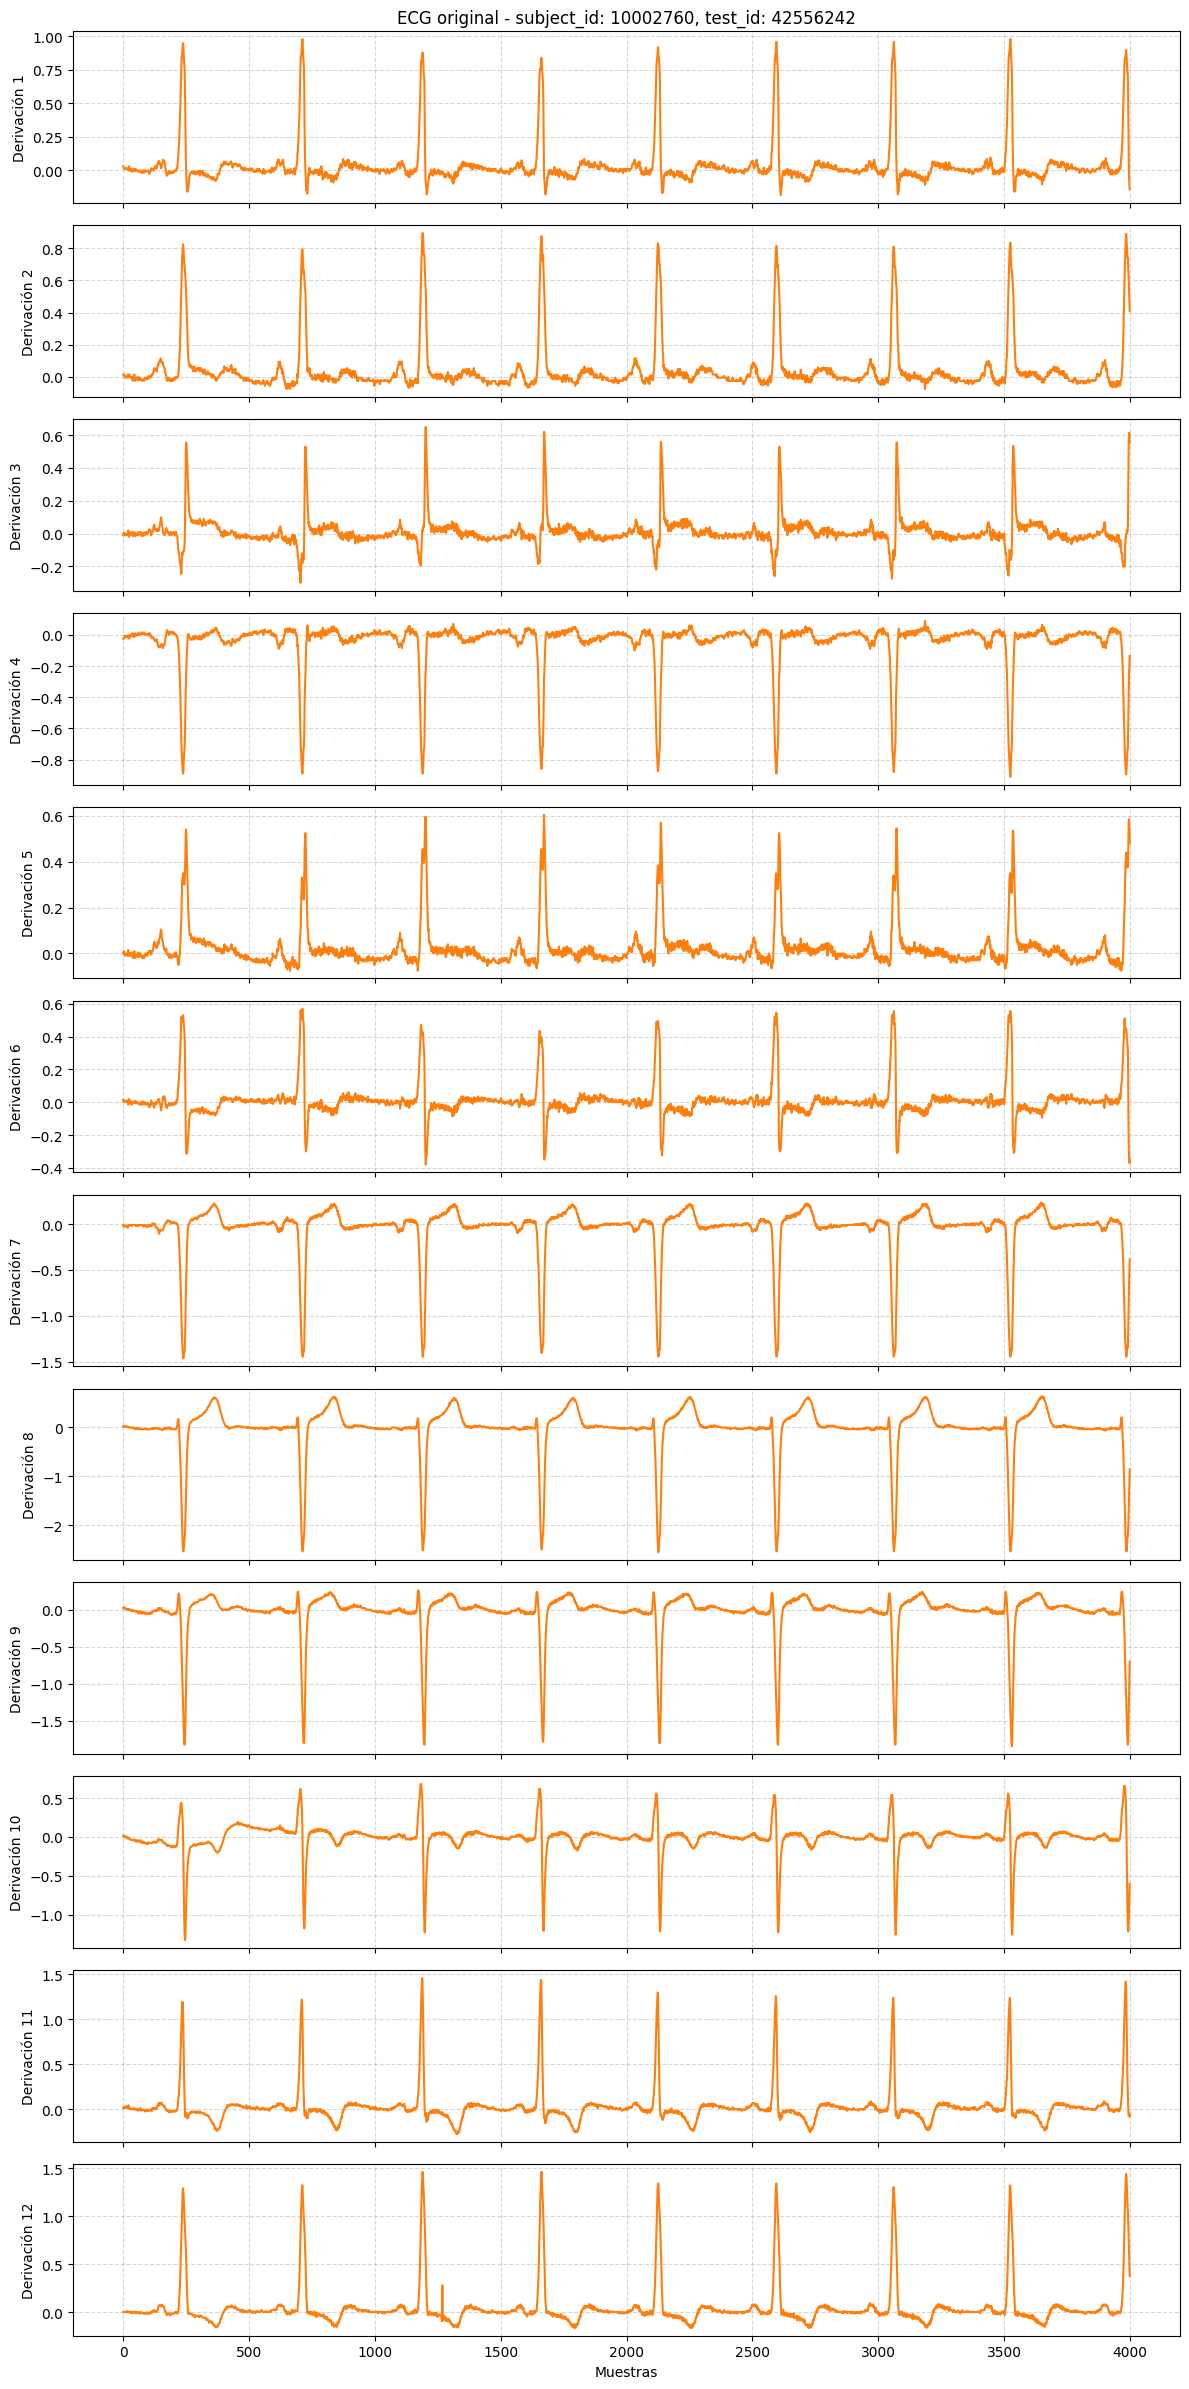

In [90]:
# Graficar las 12 derivaciones de un paciente especificando el subject_id
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ecg_by_subject(subject_id, window=4000):
    validation_log = pd.read_csv('LOGS/ecg_validation_log.csv')
    # Convertir subject_id a string para evitar problemas de tipo
    subject_id_str = str(subject_id)
    validation_log['subject_id'] = validation_log['subject_id'].astype(str)
    registros = validation_log[(validation_log['subject_id'] == subject_id_str) & (validation_log['status'] == 'OK') & (validation_log['signal_status'] == 'SIGNAL_OK')]
    if len(registros) == 0:
        print(f'No se encontró ECG válido para subject_id {subject_id}.')
        print('IDs disponibles en el log:', validation_log['subject_id'].unique()[:10], '...')
        return
    ejemplo = registros.iloc[0]
    folder = ejemplo['folder']
    hea_filename = ejemplo['hea_filename']
    record_path = f"{folder}/{hea_filename}".replace('.hea', '')
    record = wfdb.rdrecord(record_path)
    signal = record.p_signal  # Sin normalizar ni procesar
    # Seleccionar ventana de muestras
    if signal.shape[0] > window:
        signal = signal[:window, :]
    n_leads = signal.shape[1]
    fig, axes = plt.subplots(n_leads, 1, figsize=(12, 2*n_leads), sharex=True)
    for i in range(n_leads):
        axes[i].plot(signal[:, i], color='C1')
        axes[i].set_ylabel(f'Derivación {i+1}')
        axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[0].set_title(f'ECG original - subject_id: {ejemplo["subject_id"]}, test_id: {ejemplo["test_id"]}')
    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_ecg_by_subject(subject_id=10002760)  # Cambia el subject_id por el que desees visualizar

## 5 - EXPORT SPLITTED DATASET

In [89]:
# Guardar datos procesados en archivos .pt de tamaño máximo definido (por defecto 500MB) y comprimidos en zip
import torch
import os
import zipfile
import math

def save_signals_chunked(indices, dataset, out_dir, zip_name, prefix, max_mb=500):
    os.makedirs(out_dir, exist_ok=True)
    temp_files = []
    chunk = []
    chunk_labels = []
    chunk_size_bytes = 0
    max_bytes = max_mb * 1024 * 1024
    file_count = 0
    for i, idx in enumerate(indices):
        signal, label = dataset[idx]
        signal = signal.to(torch.float16)
        label = label.to(torch.float16)
        chunk.append(signal)
        chunk_labels.append(label)
        # Estimar tamaño en bytes (float16 = 2 bytes por valor)
        chunk_size_bytes += signal.numel() * 2 + label.numel() * 2
        # Si supera el límite, guardar el chunk
        if chunk_size_bytes >= max_bytes or i == len(indices)-1:
            signals_tensor = torch.stack(chunk)
            labels_tensor = torch.stack(chunk_labels)
            file_path = os.path.join(out_dir, f'{prefix}_chunk_{file_count:03d}.pt')
            torch.save({'signals': signals_tensor, 'labels': labels_tensor}, file_path, _use_new_zipfile_serialization=True)
            temp_files.append(file_path)
            chunk = []
            chunk_labels = []
            chunk_size_bytes = 0
            file_count += 1
    # Comprimir todos los archivos en un zip
    with zipfile.ZipFile(zip_name, 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in temp_files:
            zipf.write(file, arcname=os.path.basename(file))
    #for file in temp_files:
        #os.remove(file)
    print(f'Guardados y comprimidos {file_count} archivos en {zip_name} (máx {max_mb}MB por archivo)')

# Guardar train, test y val en archivos chunked y zip
save_signals_chunked(train_data, ecg_dataset, '/Volumes/KINGSTON/TORCH/train_chunks', '/Volumes/KINGSTON/TORCH/train_data_chunks.zip', 'train', max_mb=500)
save_signals_chunked(test_data, ecg_dataset, '/Volumes/KINGSTON/TORCH/test_chunks', '/Volumes/KINGSTON/TORCH/test_data_chunks.zip', 'test', max_mb=500)
save_signals_chunked(val_data, ecg_dataset, '/Volumes/KINGSTON/TORCH/val_chunks', '/Volumes/KINGSTON/TORCH/val_data_chunks.zip', 'val', max_mb=500)

# Guardar los índices para reproducibilidad
torch.save({
    '/Volumes/KINGSTON/TORCH/train_data': train_data,
    '/Volumes/KINGSTON/TORCH/test_data': test_data,
    '/Volumes/KINGSTON/TORCH/val_data': val_data,
    '/Volumes/KINGSTON/TORCH/dataset_size': len(ecg_dataset)
}, '/Volumes/KINGSTON/TORCH/split_indices.pt')

print('Datos guardados en archivos chunked y comprimidos en zip.')

Guardados y comprimidos 1 archivos en /Volumes/KINGSTON/TORCH/train_data_chunks.zip (máx 500MB por archivo)
Guardados y comprimidos 1 archivos en /Volumes/KINGSTON/TORCH/test_data_chunks.zip (máx 500MB por archivo)
Guardados y comprimidos 1 archivos en /Volumes/KINGSTON/TORCH/val_data_chunks.zip (máx 500MB por archivo)
Datos guardados en archivos chunked y comprimidos en zip.
